In [1]:
import sys
from pathlib import Path

# notebook is inside: RAG/notebooks
# project root is one level up
PROJECT_ROOT = Path.cwd().parent

# make src/ importable
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())



PROJECT_ROOT: c:\Users\Vohita\RAG
src exists: True


In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# notebook is in RAG/notebooks → project root is parent
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: c:\Users\Vohita\RAG
src exists: True
PROJECT_ROOT: c:\Users\Vohita\RAG
src exists: True


In [3]:
DATA_PATH = Path.cwd().parent / "data_legal"

In [4]:
from src.retrieval.bm25 import BM25Index
from src.retrieval.faiss import FAISSIndex
# from src.retrieval.hybridretriever import HybridRetriever
# from src.storage.metadata import MetadataStore
# from src.security.user_context import UserContext



In [5]:
# --- Load chunks ---
from pathlib import Path
import pandas as pd

# -------- PATH --------
DATA_PATH = Path(r"C:\Users\Vohita\RAG\data_legal")

# -------- LOAD CHUNKS --------
chunks = pd.read_csv(DATA_PATH / "rag_corpus_chunks.csv")
chunks = chunks.reset_index(drop=True)
chunks["row_id"] = chunks.index

documents = chunks["chunk_text"].astype(str).tolist()

print("Chunks loaded:", len(chunks))

# -------- LOAD BM25 (LEGAL) --------
from src.retrieval.bm25 import BM25Index

bm25 = BM25Index.load(
    DATA_PATH / "indexes" / "bm25_legal.pkl"
)

print("BM25 loaded")

# -------- LOAD FAISS (LEGAL) --------
import faiss

faiss_index = faiss.read_index(
    str(DATA_PATH / "indexes" / "faiss.index")
)

print("FAISS loaded. Vectors:", faiss_index.ntotal)


# # --- Metadata ---
# from src.storage.metadata import MetadataStore
# metadata_df = pd.read_csv(f"{DATA_PATH}/metadata/chunk_metadata.csv")
# metadata_store = MetadataStore(metadata_df)


Chunks loaded: 458
BM25 loaded
FAISS loaded. Vectors: 458


In [6]:
hasattr(BM25Index, "load")


True

In [7]:
# dir(metadata_store)


In [8]:
chunks = pd.read_csv(DATA_PATH / "rag_corpus_chunks.csv")
chunks = chunks.reset_index(drop=True)
chunks["row_id"] = chunks.index


In [9]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [10]:
embedder = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=device
)

In [11]:
query = "non compete restriction in license agreement"

query_embedding = embedder.encode(
    query,
    convert_to_numpy=True
).reshape(1, -1)

# user = UserContext(
#     user_id="u_test",
#     department="engineering",
#     clearance=2,
    
# )


In [12]:
# Baseline retrieval(without re-ranking)

In [13]:
# from src.retrieval.hybridretriver import HybridRetriever

# retriever = HybridRetriever(
#     bm25=bm25,
#     faiss=faiss_index,
#     metadata_store=metadata_store,
#     chunks_df=chunks,
#     reranker=None
# )
# Simple retriever bundle (LEGAL ONLY)
retriever = {
    "bm25": bm25,
    "faiss": faiss_index,
    "chunks": chunks,
    "embedder": embedder
}


In [14]:
# -------- RETRIEVE (FAISS-based baseline) --------
import faiss

# normalize query embedding (FAISS requirement)
faiss.normalize_L2(query_embedding)

scores, indices = retriever["faiss"].search(
    query_embedding,
    k=5
)

baseline_results = list(zip(indices[0], scores[0]))

baseline_results


[(113, 0.6256729),
 (451, 0.62344074),
 (252, 0.61215436),
 (408, 0.5833131),
 (410, 0.58087194)]

In [15]:
for row_id, score in baseline_results:
    print("-" * 80)
    print("row_id:", row_id, "hybrid_score:", score)
    print(chunks.iloc[row_id]["chunk_text"][:300])

--------------------------------------------------------------------------------
row_id: 113 hybrid_score: 0.6256729
During the term of this Agreement, neither Party shall, and shall not permit its Affiliates to, nor grant any rights to any Third Party to, directly or indirectly, Commercialize, or Develop any New Product for Commercialization in the Territory, except as permitted in accordance with this Section 3.
--------------------------------------------------------------------------------
row_id: 451 hybrid_score: 0.62344074
"Each of Licensor and Licensee understands and acknowledges that Licensor shall be entitled to protect and preserve the going concern value of Licensor's business to the extent permitted by law and that Licensor would not have entered into this Agreement absent the provisions of this Section 10.1 an
--------------------------------------------------------------------------------
row_id: 252 hybrid_score: 0.61215436
If THI does not make the obligatory payments 

In [16]:
# Re-ranking the retrieval(cross-encoder)

In [17]:
from sentence_transformers import CrossEncoder

In [18]:
reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device=device
)

In [19]:
pairs = [
    (query, chunks.iloc[row_id]["chunk_text"])
    for row_id, _ in baseline_results
]

In [20]:
rerank_scores = reranker.predict(pairs)
rerank_scores

array([ 0.86706233,  0.65798914, -6.1013646 , -1.8451632 , -3.1143892 ],
      dtype=float32)

In [21]:
reranked = list(zip(
    [row_id for row_id, _ in baseline_results],
    rerank_scores
))

In [22]:
baseline_results

[(113, 0.6256729),
 (451, 0.62344074),
 (252, 0.61215436),
 (408, 0.5833131),
 (410, 0.58087194)]

In [23]:
reranked_sorted = sorted(
    reranked,
    key=lambda x: x[1],
    reverse=True
)

reranked_sorted

[(113, 0.86706233),
 (451, 0.65798914),
 (408, -1.8451632),
 (410, -3.1143892),
 (252, -6.1013646)]

In [24]:
for row_id, score in reranked_sorted:
    print("-" * 80)
    print("row_id:", row_id, "rerank_score:", score)
    print(chunks.iloc[row_id]["chunk_text"][:300])

--------------------------------------------------------------------------------
row_id: 113 rerank_score: 0.86706233
During the term of this Agreement, neither Party shall, and shall not permit its Affiliates to, nor grant any rights to any Third Party to, directly or indirectly, Commercialize, or Develop any New Product for Commercialization in the Territory, except as permitted in accordance with this Section 3.
--------------------------------------------------------------------------------
row_id: 451 rerank_score: 0.65798914
"Each of Licensor and Licensee understands and acknowledges that Licensor shall be entitled to protect and preserve the going concern value of Licensor's business to the extent permitted by law and that Licensor would not have entered into this Agreement absent the provisions of this Section 10.1 an
--------------------------------------------------------------------------------
row_id: 408 rerank_score: -1.8451632
"Subject to the terms of this Agreement, sub

In [25]:
comparison = pd.DataFrame({
    "row_id": [r[0] for r in baseline_results],
    "hybrid_score": [r[1] for r in baseline_results],
    "rerank_score": rerank_scores
})

comparison

,row_id,hybrid_score,rerank_score
0,113,0.625673,0.867062
1,451,0.623441,0.657989
2,252,0.612154,-6.101365
3,408,0.583313,-1.845163
4,410,0.580872,-3.114389


In [26]:
# Modularized cross-encoder re-ranker

In [27]:
import importlib
import src.reranking.crossencoder as cross_encoder_reranker
importlib.reload(cross_encoder_reranker)

reranker = cross_encoder_reranker.CrossEncoderReranker()

In [28]:
candidate_text = []
for row_id, score in baseline_results:
    candidate_text.append(chunks.iloc[row_id]["chunk_text"])

In [29]:
reranked_sorted = sorted(
    reranked,
    key=lambda x: x[1],
    reverse=True
)

In [30]:
reranker.score(query, candidate_text)

[0.8670623302459717,
 0.6579891443252563,
 -6.101364612579346,
 -1.8451632261276245,
 -3.114389181137085]

In [31]:
reranked = list(zip(
    [row_id for row_id, _ in baseline_results],
    scores
))

In [32]:
# LLM-based reranker

In [33]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

In [34]:
pip install accelerate


Note: you may need to restart the kernel to use updated packages.


In [35]:
llm_model_name = "google/flan-t5-large"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    llm_model_name,
    device_map="auto"
)
model.eval()

C:\Users\Vohita\anaconda3\envs\phase1-retrieval\Lib\site-packages\accelerate\utils\modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['decoder.embed_tokens', 'encoder.embed_tokens']
  warnings.warn(
Some parameters are on the meta device because they were offloaded to the disk and cpu.


T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
              (wi_1): Linear(in_features=1024, out_features=2816, bias=False)
       

In [36]:
def build_rerank_prompt(query: str, context: str) -> str:
    return f"""
You are a relevance judge.

User query:
"{query}"

Candidate document:
"{context}"

Task:
Score how relevant the document is to answering the query.

Rules:
- Respond with a single integer from 0 to 5
- 0 = not relevant at all
- 5 = directly answers the query
- Do NOT explain your answer

Score:
""".strip()

In [37]:
def llm_rerank(query: str, candidate_texts: list[str]) -> list[int]:
    scores = []

    for text in candidate_texts:
        prompt = build_rerank_prompt(query, text)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(model.device)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=5
            )

        response = tokenizer.decode(output[0], skip_special_tokens=True)

        try:
            score = int(response.strip())
        except ValueError:
            score = 0

        scores.append(score)

    return scores


In [38]:
candidate_texts = [
    chunks.iloc[row_id]["chunk_text"]
    for row_id, _ in baseline_results
]

In [39]:
llm_scores = llm_rerank(query, candidate_texts)
llm_scores

[3, 3, 0, 3, 3]

In [40]:
llm_reranked = list(zip(
    [row_id for row_id, _ in baseline_results],
    llm_scores
))

In [41]:
llm_reranked_sorted = sorted(
    llm_reranked,
    key=lambda x: x[1],
    reverse=True
)

llm_reranked_sorted

[(113, 3), (451, 3), (408, 3), (410, 3), (252, 0)]

In [42]:
# Hybrid retrieval with re-ranke

In [43]:
import importlib

# reload BM25 (you use this)
import src.retrieval.bm25 as bm25_module
importlib.reload(bm25_module)

# reload tokenization (BM25 depends on it)
import src.retrieval.tokenization as tokenization_module
importlib.reload(tokenization_module)

# reload reranker (you confirmed you use it)
import src.reranking.crossencoder as cross_encoder
importlib.reload(cross_encoder)

print("Retrieval + reranker modules reloaded ✅")


Retrieval + reranker modules reloaded ✅


In [44]:
retriever = {
    "retrieve": lambda query, query_embedding, top_k=5: retrieve_with_rerank(
        query=query,
        query_embedding=query_embedding,
        bm25=bm25,
        faiss_index=faiss_index,
        chunks=chunks,
        reranker=reranker,
        top_k=top_k
    )
}



In [45]:
retriever


{'retrieve': <function __main__.<lambda>(query, query_embedding, top_k=5)>}

In [46]:
import src.retrieval
dir(src.retrieval)


['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'bm25',
 'faiss',
 'tokenization']

In [47]:
# from src.retrieval.hybridretriver import HybridRetriever
from src.reranking import crossencoder


In [48]:
reranker = crossencoder.CrossEncoderReranker()


In [49]:
import faiss

def retrieve(
    query,
    query_embedding,
    bm25,
    faiss_index,
    chunks,
    reranker,
    top_k=5
):
    # ---- FAISS retrieval ----
    faiss.normalize_L2(query_embedding)

    scores, indices = faiss_index.search(
        query_embedding,
        k=50
    )

    row_ids = indices[0].tolist()

    texts = [
        chunks.iloc[row_id]["chunk_text"]
        for row_id in row_ids
    ]

    # ---- RERANK ----
    rerank_scores = reranker.predict(
        [(query, text) for text in texts]
    )

    # ---- Sort by reranker score ----
    reranked = sorted(
        zip(row_ids, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    return reranked[:top_k]


In [50]:
retriever = {
    "bm25": bm25,
    "faiss": faiss_index,
    "chunks": chunks,
    "reranker": reranker,
    "retrieve": lambda query, query_embedding, top_k=5: retrieve(
        query=query,
        query_embedding=query_embedding,
        bm25=bm25,
        faiss_index=faiss_index,
        chunks=chunks,
        reranker=reranker,
        top_k=top_k
    )
}



In [51]:
# Hybrid retrieval without re-ranker

In [52]:
import faiss

def retrieve_wo_reranker(
    query,
    query_embedding,
    bm25,
    faiss_index,
    chunks,
    top_k=5
):
    # ----- FAISS retrieval -----
    faiss.normalize_L2(query_embedding)

    scores, indices = faiss_index.search(
        query_embedding,
        k=50
    )

    faiss_results = list(zip(indices[0], scores[0]))

    # ----- BM25 retrieval -----
    bm25_results = bm25.search(
        query=query,
        k=50
    )

    # ----- Merge scores -----
    combined = {}

    for row_id, score in faiss_results:
        combined[row_id] = combined.get(row_id, 0) + score

    for row_id, score in bm25_results:
        combined[row_id] = combined.get(row_id, 0) + score

    # ----- Rank -----
    ranked = sorted(
        combined.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:top_k]



In [53]:
retriever_wo_reranker = {
    "retrieve": lambda query, query_embedding, top_k=5: retrieve_wo_reranker(
        query=query,
        query_embedding=query_embedding,
        bm25=bm25,
        faiss_index=faiss_index,
        chunks=chunks,
        top_k=top_k
    )
}


In [54]:

# Final retrieval test

In [55]:
import importlib

# reload retrieval modules you actually use
import src.retrieval.bm25 as bm25_module
import src.retrieval.tokenization as tokenization_module

# reload reranker module you are using
import src.reranking.crossencoder as cross_encoder

importlib.reload(bm25_module)
importlib.reload(tokenization_module)
importlib.reload(cross_encoder)

print("Retrieval + reranker modules reloaded ")



Retrieval + reranker modules reloaded 


In [56]:
query = "non compete restriction in license agreement"

query_embedding = embedder.encode(
    query,
    convert_to_numpy=True
).reshape(1, -1)

# user = UserContext(
#     user_id="u_test",
#     department="engineering",
#     clearance=2,
#     projects=[]
# )

In [57]:
import faiss

def retrieve_no_rerank(
    query,
    query_embedding,
    bm25,
    faiss_index,
    chunks,
    top_k=5
):
    # normalize query embedding
    faiss.normalize_L2(query_embedding)

    # FAISS retrieval
    faiss_scores, faiss_indices = faiss_index.search(
        query_embedding,
        k=50
    )

    faiss_results = list(zip(faiss_indices[0], faiss_scores[0]))

    # BM25 retrieval
    bm25_results = bm25.search(
        query=query,
        k=50
    )

    # merge scores
    combined_scores = {}

    for row_id, score in faiss_results:
        combined_scores[row_id] = combined_scores.get(row_id, 0) + score

    for row_id, score in bm25_results:
        combined_scores[row_id] = combined_scores.get(row_id, 0) + score

    # rank and return top_k
    ranked = sorted(
        combined_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:top_k]


In [58]:
retriever_no_rerank = {
    "retrieve": lambda query, query_embedding, top_k=5: retrieve_no_rerank(
        query=query,
        query_embedding=query_embedding,
        bm25=bm25,
        faiss_index=faiss_index,
        chunks=chunks,
        top_k=top_k
    )
}

 

In [59]:
results_no_rerank = retriever_no_rerank["retrieve"](
    query=query,
    query_embedding=query_embedding,
    top_k=5
)

results_no_rerank


[(17, 6.9276046738876484),
 (0, 5.577560142569897),
 (4, 4.575469060519126),
 (45, 4.463741134862946),
 (42, 4.3489267351138245)]

In [60]:
print("=== Hybrid Retrieval (NO RERANKER) ===")

for i, (row_id, score) in enumerate(results_no_rerank, start=1):
    print(f"\nRank {i} | row_id={row_id} | hybrid_score={score:.4f}")
    print(chunks.iloc[row_id]["chunk_text"][:300])

=== Hybrid Retrieval (NO RERANKER) ===

Rank 1 | row_id=17 | hybrid_score=6.9276
The Distributor shall not:<omitted>act as the agent or the buying agent, for any person for any goods which are competitive with the Product; or

Rank 2 | row_id=0 | hybrid_score=5.5776
Company shall not specify the business practices of MA, nor regulate the manner in which MA shall operate its business, provided that MA (a) conducts business in a manner that reflects favorably at all times on the Technology sold and the good name, goodwill and reputation of Company and its affilia

Rank 3 | row_id=4 | hybrid_score=4.5755
During the Term, (a) Women.com will not buy, sell, display, distribute advertising from (including, but not limited to, banner ads, buttons, badges, text links, hyperlinks or editorial mentions) or otherwise promote a Competitive Company on any page of the Diet Center;<omitted>(c) Women.com will not

Rank 4 | row_id=45 | hybrid_score=4.4637
Throughout the Term and for a period of six (6) 

In [100]:
import faiss

def retrieve_with_rerank(
    query,
    query_embedding,
    bm25,
    faiss_index,
    chunks,
    reranker,
    top_k=5
):
    # ---- Normalize query embedding ----
    faiss.normalize_L2(query_embedding)

    # ---- FAISS retrieval ----
    faiss_scores, faiss_indices = faiss_index.search(
        query_embedding,
        k=50
    )

    faiss_results = list(zip(faiss_indices[0], faiss_scores[0]))

    # ---- BM25 retrieval ----
    bm25_results = bm25.search(
        query=query,
        k=50
    )

    # ---- Merge scores (Hybrid candidate pool) ----
    combined_scores = {}

    for row_id, score in faiss_results:
        combined_scores[row_id] = combined_scores.get(row_id, 0) + score

    for row_id, score in bm25_results:
        combined_scores[row_id] = combined_scores.get(row_id, 0) + score

    # ---- Select top 50 hybrid candidates ----
    hybrid_ranked = sorted(
        combined_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:50]

    row_ids = [r[0] for r in hybrid_ranked]

    texts = [
        chunks.iloc[row_id]["chunk_text"]
        for row_id in row_ids
    ]

    # ---- Cross-Encoder Reranking ----
    if hasattr(reranker, "score"):
        rerank_scores = reranker.score(
            query=query,
            candidate_texts=texts
        )
    elif hasattr(reranker, "rerank"):
        rerank_scores = reranker.rerank(query, texts)
    else:
        raise AttributeError(
            "CrossEncoderReranker has no score() or rerank() method"
        )

    # ---- Final ranking by reranker ----
    reranked = sorted(
        zip(row_ids, rerank_scores),
        key=lambda x: x[1],
        reverse=True
    )

    return reranked[:top_k]



In [101]:
retriever_with_rerank = {
    "retrieve": lambda query, query_embedding, top_k=5: retrieve_with_rerank(
        query=query,
        query_embedding=query_embedding,
        bm25=bm25,
        faiss_index=faiss_index,
        chunks=chunks,
        reranker=reranker,
        top_k=top_k
    )
}


In [102]:
results_with_rerank = retriever_with_rerank["retrieve"](
    query=query,
    query_embedding=query_embedding,
    top_k=5
)

results_with_rerank


[(11, 2.8156578540802),
 (113, 0.8670623302459717),
 (451, 0.6579891443252563),
 (3, 0.6497054100036621),
 (450, 0.43568336963653564)]

In [103]:
print("=== Hybrid Retrieval (WITH CROSS-ENCODER RERANKER) ===")

for i, (row_id, score) in enumerate(results_with_rerank, start=1):
    print(f"\nRank {i} | row_id={row_id} | rerank_score={score:.4f}")
    print(chunks.iloc[row_id]["chunk_text"][:300])

=== Hybrid Retrieval (WITH CROSS-ENCODER RERANKER) ===

Rank 1 | row_id=11 | rerank_score=2.8157
Notwithstanding any portion of the foregoing to the contrary, the Non-Competition Period shall terminate prior to the End Date, and for the avoidance of doubt, no party shall be obligated to comply with the restrictions set out in Section 8.1 after the termination of the Non-Competition Period:', 'E

Rank 2 | row_id=113 | rerank_score=0.8671
During the term of this Agreement, neither Party shall, and shall not permit its Affiliates to, nor grant any rights to any Third Party to, directly or indirectly, Commercialize, or Develop any New Product for Commercialization in the Territory, except as permitted in accordance with this Section 3.

Rank 3 | row_id=451 | rerank_score=0.6580
"Each of Licensor and Licensee understands and acknowledges that Licensor shall be entitled to protect and preserve the going concern value of Licensor's business to the extent permitted by law and that Licensor wou

In [104]:
comparison = pd.DataFrame({
    "rank_no_rerank": [i+1 for i in range(len(results_no_rerank))],
    "row_id_no_rerank": [r[0] for r in results_no_rerank],
    "rank_with_rerank": [i+1 for i in range(len(results_with_rerank))],
    "row_id_with_rerank": [r[0] for r in results_with_rerank],
})

comparison

,rank_no_rerank,row_id_no_rerank,rank_with_rerank,row_id_with_rerank
0,1,17,1,11
1,2,0,2,113
2,3,4,3,451
3,4,45,4,3
4,5,42,5,450


In [105]:
ground_truth = pd.read_csv(DATA_PATH / "ground_truth.csv")

In [106]:
print(chunks.columns)
print(ground_truth.columns)

Index(['chunk_id', 'doc_id', 'domain', 'chunk_index', 'estimated_tokens',
       'chunk_text', 'row_id'],
      dtype='object')
Index(['query', 'chunk_id'], dtype='object')


In [107]:
gt_map = dict(zip(ground_truth["query"], ground_truth["chunk_id"]))

In [108]:
import numpy as np

def evaluate_retriever(retriever_dict, top_k=5):

    precision_scores = []
    recall_scores = []
    mrr_scores = []

    for query, relevant_chunk_id in gt_map.items():

        # Encode query
        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        # Retrieve
        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=top_k
        )

        # Convert row_id → chunk_id
        retrieved_chunk_ids = [
            chunks.iloc[r[0]]["chunk_id"]
            for r in results
        ]

        hit = int(relevant_chunk_id in retrieved_chunk_ids)

        # Recall@K
        recall_scores.append(hit)

        # Precision@K
        precision_scores.append(hit / top_k)

        # MRR
        if relevant_chunk_id in retrieved_chunk_ids:
            rank = retrieved_chunk_ids.index(relevant_chunk_id) + 1
            mrr_scores.append(1 / rank)
        else:
            mrr_scores.append(0)

    return {
        f"Precision@{top_k}": np.mean(precision_scores),
        f"Recall@{top_k}": np.mean(recall_scores),
        "MRR": np.mean(mrr_scores)
    }

In [109]:
def evaluate_retriever(retriever_dict, top_k=5, max_queries=50):

    precision_scores = []
    recall_scores = []
    mrr_scores = []

    for i, (query, relevant_chunk_id) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=top_k
        )

        retrieved_chunk_ids = [
            chunks.iloc[r[0]]["chunk_id"]
            for r in results
        ]

        hit = int(relevant_chunk_id in retrieved_chunk_ids)

        recall_scores.append(hit)
        precision_scores.append(hit / top_k)

        if relevant_chunk_id in retrieved_chunk_ids:
            rank = retrieved_chunk_ids.index(relevant_chunk_id) + 1
            mrr_scores.append(1 / rank)
        else:
            mrr_scores.append(0)

    return {
        f"Precision@{top_k}": np.mean(precision_scores),
        f"Recall@{top_k}": np.mean(recall_scores),
        "MRR": np.mean(mrr_scores)
    }

In [110]:
hybrid_results = evaluate_retriever(retriever_no_rerank, top_k=5, max_queries=50)
rerank_results = evaluate_retriever(retriever_with_rerank, top_k=5, max_queries=50)

print("Hybrid (No Rerank):", hybrid_results)
print("Hybrid + CrossEncoder:", rerank_results)

Hybrid (No Rerank): {'Precision@5': 0.016, 'Recall@5': 0.08, 'MRR': 0.03833333333333333}
Hybrid + CrossEncoder: {'Precision@5': 0.17999999999999997, 'Recall@5': 0.9, 'MRR': 0.8566666666666667}


In [72]:
hybrid_results = evaluate_retriever(retriever_no_rerank, top_k=5, max_queries=10)

In [73]:
print(hybrid_results)

{'Precision@5': 0.02, 'Recall@5': 0.1, 'MRR': 0.03333333333333333}


In [74]:
rerank_results = evaluate_retriever(
    retriever_with_rerank,
    top_k=5,
    max_queries=10
)

print(rerank_results)

{'Precision@5': 0.2, 'Recall@5': 1.0, 'MRR': 1.0}


In [111]:
candidate_texts = [
    chunks.iloc[row_id]["chunk_text"]
    for row_id, _ in baseline_results
]

In [76]:
hybrid_results = evaluate_retriever(retriever_no_rerank, top_k=5, max_queries=70)
rerank_results = evaluate_retriever(retriever_with_rerank, top_k=5, max_queries=70)

print("Hybrid (No Rerank):", hybrid_results)
print("Hybrid + CrossEncoder:", rerank_results)

Hybrid (No Rerank): {'Precision@5': 0.017142857142857144, 'Recall@5': 0.08571428571428572, 'MRR': 0.03452380952380952}
Hybrid + CrossEncoder: {'Precision@5': 0.1828571428571428, 'Recall@5': 0.9142857142857143, 'MRR': 0.8516666666666667}


In [112]:
hybrid_results = evaluate_retriever(retriever_no_rerank, top_k=5, max_queries=100)
rerank_results = evaluate_retriever(retriever_with_rerank, top_k=5, max_queries=100)

print("Hybrid (No Rerank):", hybrid_results)
print("Hybrid + CrossEncoder:", rerank_results)

Hybrid (No Rerank): {'Precision@5': 0.012000000000000002, 'Recall@5': 0.06, 'MRR': 0.024166666666666666}
Hybrid + CrossEncoder: {'Precision@5': 0.16199999999999995, 'Recall@5': 0.81, 'MRR': 0.7583333333333334}


In [113]:
import time
import numpy as np

def measure_latency(retriever_dict, max_queries=50):

    times = []

    for i, (query, _) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        start = time.time()

        _ = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=5
        )

        end = time.time()

        times.append(end - start)

    return {
        "avg_time_per_query_sec": np.mean(times),
        "std_time_sec": np.std(times)
    }

In [114]:
hybrid_time = measure_latency(retriever_no_rerank, max_queries=20)
rerank_time = measure_latency(retriever_with_rerank, max_queries=20)

print("Hybrid Time:", hybrid_time)
print("Hybrid + CrossEncoder Time:", rerank_time)

Hybrid Time: {'avg_time_per_query_sec': 0.0032215356826782227, 'std_time_sec': 0.001015147015622802}
Hybrid + CrossEncoder Time: {'avg_time_per_query_sec': 8.355275654792786, 'std_time_sec': 0.691043294157902}


In [115]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import numpy as np

def collect_scores(retriever_dict, max_queries=100):

    y_true = []
    y_scores = []

    for i, (query, relevant_chunk_id) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=50   # use larger pool for curve
        )

        for row_id, score in results:
            chunk_id = chunks.iloc[row_id]["chunk_id"]

            y_true.append(1 if chunk_id == relevant_chunk_id else 0)
            y_scores.append(score)

    return np.array(y_true), np.array(y_scores)

In [116]:
y_true, y_scores = collect_scores(
    retriever_with_rerank,
    max_queries=100
)

In [117]:
print("Total samples:", len(y_true))
print("Positive samples:", sum(y_true))

Total samples: 5000
Positive samples: 84


In [118]:
precision, recall, _ = precision_recall_curve(y_true, y_scores)

In [119]:
print("Precision array length:", len(precision))
print("Recall array length:", len(recall))

Precision array length: 4940
Recall array length: 4940


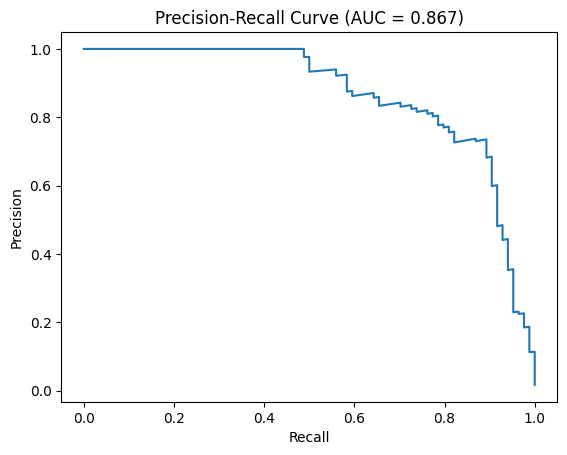

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")
plt.show()

In [121]:
# Collect scores for Hybrid (No Rerank)

y_true_hybrid, y_scores_hybrid = collect_scores(
    retriever_no_rerank,
    max_queries=100
)

print("Hybrid samples:", len(y_true_hybrid))
print("Hybrid positives:", sum(y_true_hybrid))

Hybrid samples: 5000
Hybrid positives: 84


In [122]:
from sklearn.metrics import precision_recall_curve, auc

precision_h, recall_h, _ = precision_recall_curve(
    y_true_hybrid,
    y_scores_hybrid
)

pr_auc_hybrid = auc(recall_h, precision_h)

print("Hybrid PR-AUC:", pr_auc_hybrid)

Hybrid PR-AUC: 0.014234923277786478


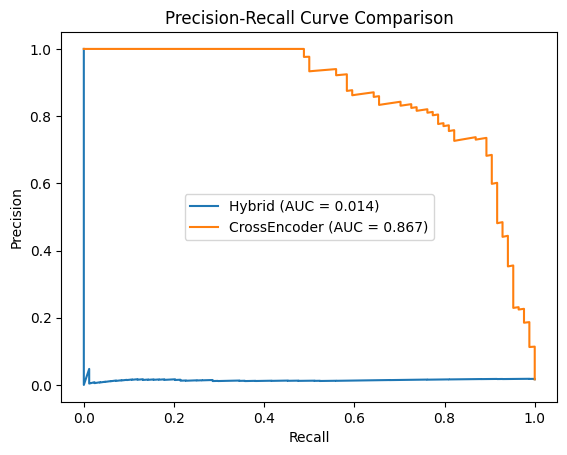

In [123]:
import matplotlib.pyplot as plt

# CrossEncoder curve (you already computed)
precision_ce, recall_ce = precision, recall
pr_auc_ce = pr_auc

plt.figure()

plt.plot(recall_h, precision_h, label=f"Hybrid (AUC = {pr_auc_hybrid:.3f})")
plt.plot(recall_ce, precision_ce, label=f"CrossEncoder (AUC = {pr_auc_ce:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()

In [124]:
import numpy as np

def collect_rank_positions(retriever_dict, max_queries=100):

    ranks = []

    for i, (query, relevant_chunk_id) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=50
        )

        retrieved_chunk_ids = [
            chunks.iloc[r[0]]["chunk_id"]
            for r in results
        ]

        if relevant_chunk_id in retrieved_chunk_ids:
            rank_position = retrieved_chunk_ids.index(relevant_chunk_id) + 1
            ranks.append(rank_position)
        else:
            ranks.append(51)  # Not found in top-50

    return ranks

In [125]:
hybrid_ranks = collect_rank_positions(
    retriever_no_rerank,
    max_queries=100
)

rerank_ranks = collect_rank_positions(
    retriever_with_rerank,
    max_queries=100
)

print("Hybrid avg rank:", np.mean(hybrid_ranks))
print("CrossEncoder avg rank:", np.mean(rerank_ranks))

Hybrid avg rank: 30.31
CrossEncoder avg rank: 9.55


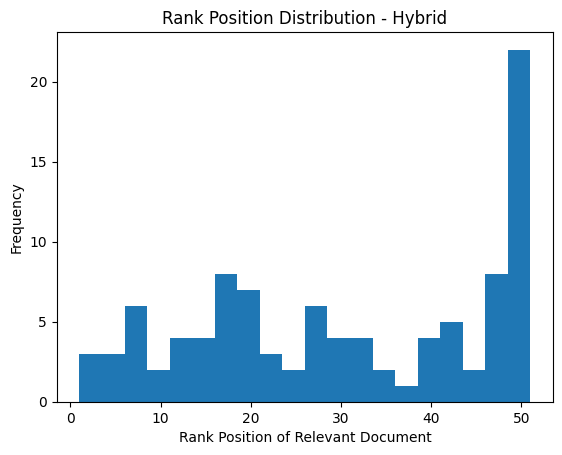

In [126]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(hybrid_ranks, bins=20)
plt.xlabel("Rank Position of Relevant Document")
plt.ylabel("Frequency")
plt.title("Rank Position Distribution - Hybrid")
plt.show()

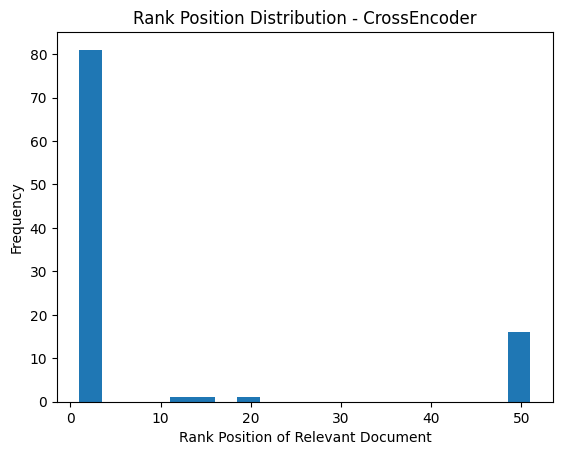

In [127]:
plt.figure()
plt.hist(rerank_ranks, bins=20)
plt.xlabel("Rank Position of Relevant Document")
plt.ylabel("Frequency")
plt.title("Rank Position Distribution - CrossEncoder")
plt.show()

In [128]:
from scipy.stats import wilcoxon
import numpy as np

def collect_recall_at_5(retriever_dict, max_queries=100):

    recall_list = []

    for i, (query, relevant_chunk_id) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=5
        )

        retrieved_chunk_ids = [
            chunks.iloc[r[0]]["chunk_id"]
            for r in results
        ]

        if relevant_chunk_id in retrieved_chunk_ids:
            recall_list.append(1)
        else:
            recall_list.append(0)

    return np.array(recall_list)

In [129]:
hybrid_recall = collect_recall_at_5(
    retriever_no_rerank,
    max_queries=100
)

rerank_recall = collect_recall_at_5(
    retriever_with_rerank,
    max_queries=100
)

print("Hybrid hits:", sum(hybrid_recall))
print("CrossEncoder hits:", sum(rerank_recall))

Hybrid hits: 6
CrossEncoder hits: 81


In [130]:
stat, p_value = wilcoxon(hybrid_recall, rerank_recall)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 0.0
p-value: 4.707140590140388e-18


In [131]:
import numpy as np

def compute_candidate_recall_at_50(retriever_dict, max_queries=100):

    hits = 0
    total = 0

    for i, (query, relevant_chunk_id) in enumerate(gt_map.items()):

        if i >= max_queries:
            break

        total += 1

        query_embedding = embedder.encode(
            query,
            convert_to_numpy=True
        ).astype("float32").reshape(1, -1)

        results = retriever_dict["retrieve"](
            query=query,
            query_embedding=query_embedding,
            top_k=50   # Important: top-50 candidate pool
        )

        retrieved_chunk_ids = [
            chunks.iloc[r[0]]["chunk_id"]
            for r in results
        ]

        if relevant_chunk_id in retrieved_chunk_ids:
            hits += 1

    recall_50 = hits / total

    return {
        "Candidate_Recall@50": recall_50,
        "Hits": hits,
        "Total_Queries": total
    }

In [132]:
candidate_stats = compute_candidate_recall_at_50(
    retriever_no_rerank,
    max_queries=100
)

print(candidate_stats)

{'Candidate_Recall@50': 0.84, 'Hits': 84, 'Total_Queries': 100}


In [98]:
print(len(hybrid_recall))
print(len(rerank_recall))

100
100


In [99]:
print(candidate_stats["Total_Queries"])

100
